<a href="https://colab.research.google.com/github/sanAkel/ufs_diagnostics/blob/main/HAFS/hafs_atcf_best_track.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Best track from tropycal
!pip install tropycal

# Install cartopy for advanced mapping capabilities
!pip install cartopy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 27.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for tropycal: filename=tropycal-1.4-py3-none-any.whl size=242893 sha256=368015a2a2e290c9a25f588505a1c411a43eb0644d729a5cd21629946004b2b9
  Stored in directory: /root/.cache/pip/wheels/1a/8e/1d/76c6127f82dea26846e4b61d5e4c0ef3142fcb874b69b46b01
Successfully built tropycal
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 62.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import requests
import io

from tqdm.notebook import tqdm # For progress bar

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.cm as cm # Import colormap functionality
import tropycal.tracks as tracks # Import tropycal for best track data

## User Input

Define the storm details and forecast date range for the spaghetti plot.

In [3]:
# --- Storm Parameters for ERIN ---
#user_storm_name = 'ERIN'     # New storm name
#user_storm_id = '05L'        # New storm ID
#user_year = 2025             # Year
#user_month = 8               # Month
#user_day = 12                # Day
#user_hour = 0                # Default to 0 UTC
fetch_frequency = '24h'      # Frequency of forecast snapshots # ('6h', '12h', '24h')

# --- Storm Parameters ---
user_storm_name = 'MELISSA'
user_storm_id = '13L'
user_year = 2025
user_month = 10
user_day = 22
user_hour = 0

# --- Forecast Date Range for Spaghetti Plot ---
# Calculating start and end dates based on the pattern of 4-day forecast window
start_date_str = f"{user_year:04d}-{user_month:02d}-{user_day:02d} {user_hour:02d}:00"

end_date_dt = pd.to_datetime(start_date_str) + pd.Timedelta(days=4)
end_date_str = end_date_dt.strftime('%Y-%m-%d %H:00')

print(f"Storm parameters set for {user_storm_name} ({user_storm_id}) in {user_year}.")
print(f"Forecast will run from {start_date_str} to {end_date_str} with a fetch frequency of {fetch_frequency}.")

Storm parameters set for MELISSA (13L) in 2025.
Forecast will run from 2025-10-22 00:00 to 2025-10-26 00:00 with a fetch frequency of 24h.


In [4]:
def get_storm_track(atcf_url):
    print("Fetching ATCF file...")
    response = requests.get(atcf_url)
    response.raise_for_status()

    # Define the first 11 core columns of the ATCF format
    # We ignore the wind radii quadrants (cols 12+) to keep the DataFrame clean
    col_names = [
        'basin', 'cyc_num', 'init_time', 'tech_num', 'model',
        'fhr', 'lat_str', 'lon_str', 'vmax', 'mslp', 'storm_type'
    ]

    # Read directly from the web response into Pandas
    df = pd.read_csv(
        io.StringIO(response.text),
        header=None,
        usecols=range(11),
        names=col_names
    )

    # Strip pesky legacy whitespace from string columns
    df['lat_str'] = df['lat_str'].str.strip()
    df['lon_str'] = df['lon_str'].str.strip()

    # ATCF repeats the forecast hour (fhr) for 34, 50, and 64 knot wind radii.
    # We only need the center track, so we drop duplicate forecast hours.
    df = df.drop_duplicates(subset=['fhr']).copy()

    # Coordinate conversion helper function
    def convert_atcf_coord(coord_str):
        # ATCF format: '284N' -> value is 284, direction is 'N'
        val = float(coord_str[:-1]) / 10.0
        direction = coord_str[-1].upper()

        # South and West are negative degrees in decimal formats
        if direction in ['S', 'W']:
            val *= -1.0
        return val

    # Apply conversions
    df['lat'] = df['lat_str'].apply(convert_atcf_coord)
    df['lon'] = df['lon_str'].apply(convert_atcf_coord)

    # Filter out filler/null values for MSLP (sometimes stored as 0 or 9999 in early storm stages)
    df = df[df['mslp'] > 0]

    # Reorder into a clean, intuitive DataFrame
    track_df = df[['fhr', 'lat', 'lon', 'vmax', 'mslp']].reset_index(drop=True)
    return track_df

In [5]:
def generate_atcf_url(storm_name, storm_id, year, month, day, hour):
    """Generates a NOAA ATCF URL for a given storm and forecast time.

    Args:
        storm_name (str): The name of the storm (e.g., 'MELISSA').
        storm_id (str): The storm identifier (e.g., '13L').
        year (int): The year of the forecast (e.g., 2025).
        month (int): The month of the forecast (e.g., 10).
        day (int): The day of the forecast (e.g., 22).
        hour (int): The hour of the forecast (e.g., 0, 6, 12, 18).

    Returns:
        str: The constructed ATCF URL.
    """
    # Example: https://www.emc.ncep.noaa.gov/hurricane/HFSAForecast/RT2025_NATL/MELISSA13L/MELISSA13L.2025102200/13l.2025102200.hfsa.trak.atcfunix
    basin = 'NATL' # Assuming North Atlantic as per example
    forecast_timestamp = f"{year:04d}{month:02d}{day:02d}{hour:02d}"

    base_url = f"https://www.emc.ncep.noaa.gov/hurricane/HFSAForecast/RT{year}_{basin}/{storm_name}{storm_id}/"
    full_url = f"{base_url}{storm_name}{storm_id}.{forecast_timestamp}/{storm_id.lower()}.{forecast_timestamp}.hfsa.trak.atcfunix"

    return full_url

Use this flexible function to generate URLs, let's create a list of URLs for multiple forecast cycles, which is useful for generating 'spaghetti plots' of forecasts.

In [6]:
# Define the date range and forecast hours using user inputs
start_date = pd.to_datetime(start_date_str)
end_date = pd.to_datetime(end_date_str)

# Generate a series of dates and hours at specified intervals
forecast_times = pd.date_range(start=start_date, end=end_date, freq=fetch_frequency)

# Generate URLs for each forecast time using user inputs
forecast_urls = []
for dt in forecast_times:
    forecast_url = generate_atcf_url(
        storm_name=user_storm_name,
        storm_id=user_storm_id,
        year=dt.year,
        month=dt.month,
        day=dt.day,
        hour=dt.hour
    )
    forecast_urls.append(forecast_url)

print("Generated URLs for spaghetti plots:")
for i, f_url in enumerate(forecast_urls):
    print(f"  {i+1}. {f_url}")

Generated URLs for spaghetti plots:
  1. https://www.emc.ncep.noaa.gov/hurricane/HFSAForecast/RT2025_NATL/MELISSA13L/MELISSA13L.2025102200/13l.2025102200.hfsa.trak.atcfunix
  2. https://www.emc.ncep.noaa.gov/hurricane/HFSAForecast/RT2025_NATL/MELISSA13L/MELISSA13L.2025102300/13l.2025102300.hfsa.trak.atcfunix
  3. https://www.emc.ncep.noaa.gov/hurricane/HFSAForecast/RT2025_NATL/MELISSA13L/MELISSA13L.2025102400/13l.2025102400.hfsa.trak.atcfunix
  4. https://www.emc.ncep.noaa.gov/hurricane/HFSAForecast/RT2025_NATL/MELISSA13L/MELISSA13L.2025102500/13l.2025102500.hfsa.trak.atcfunix
  5. https://www.emc.ncep.noaa.gov/hurricane/HFSAForecast/RT2025_NATL/MELISSA13L/MELISSA13L.2025102600/13l.2025102600.hfsa.trak.atcfunix


Fetching and processing track data from all forecasts...


Processing Forecasts:   0%|          | 0/5 [00:00<?, ?it/s]

Fetching ATCF file...
Fetching ATCF file...
Fetching ATCF file...
Fetching ATCF file...
Fetching ATCF file...
Successfully processed 5 tracks.
--> Starting to read in HURDAT2 data
--> Completed reading in HURDAT2 data (2.85 seconds)


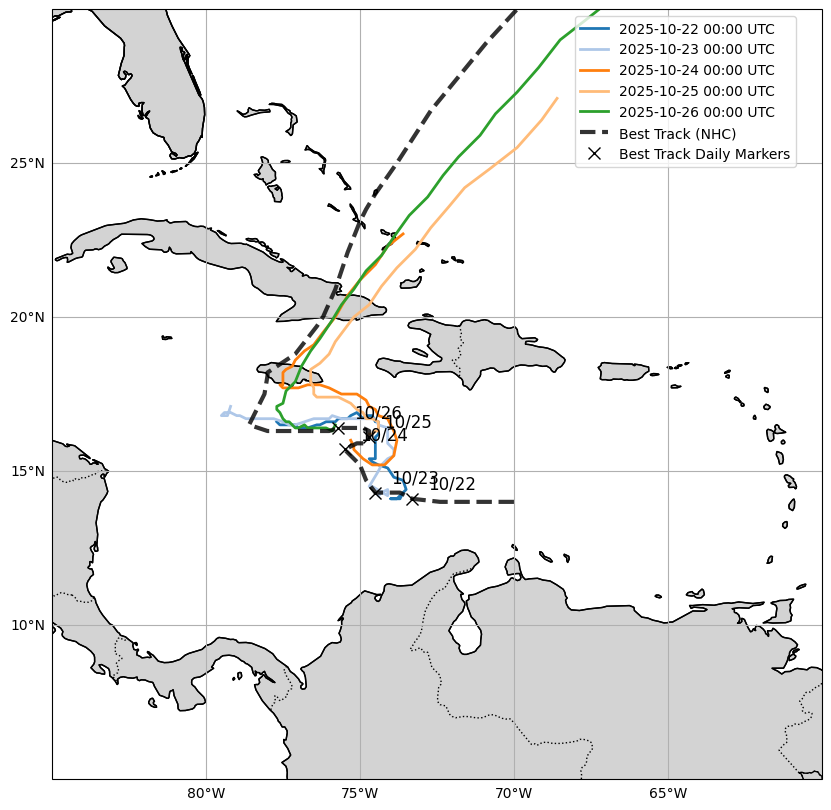

In [11]:
# --- Data Processing and Collection for Spaghetti Plot ---
all_tracks = []
peak_intensities = []

print("Fetching and processing track data from all forecasts...")
for i, url in enumerate(tqdm(forecast_urls, desc="Processing Forecasts")):
    try:
        track_df = get_storm_track(url)
        if not track_df.empty:
            all_tracks.append((track_df, forecast_times[i]))
            # Find the row where MSLP is at its absolute lowest for this forecast
            peak_intensity_point = track_df.loc[track_df['mslp'].idxmin()]
            peak_intensities.append(peak_intensity_point)
        else:
            print(f"Warning: No track data found for URL: {url}")
    except requests.exceptions.RequestException as e:
        print(f"Error fetching data from {url}: {e}")
    except Exception as e:
        print(f"An unexpected error occurred for {url}: {e}")

print(f"Successfully processed {len(all_tracks)} tracks.")

# --- Fetch Best Track Data ---
basin = tracks.TrackDataset(basin='north_atlantic',source='hurdat',include_btk=False)

# Get the best track for the user-defined storm
best_track = basin.get_storm((user_storm_name.lower(), user_year)).to_dataframe()

# --- Plotting the Spaghetti Plot ---

fig = plt.figure(figsize=(18, 10)) # Increase figure width to accommodate legend
# Use a Plate Carree projection, good for showing global or regional data
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle='-')
ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray')
# ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# Set an appropriate extent for the region of interest (e.g., North Atlantic/Caribbean)
# Adjust these limits based on the actual storm tracks
min_lon = -85
max_lon = -60
min_lat = 5
max_lat = 30
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Add gridlines
gridlines = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gridlines.top_labels = False
gridlines.right_labels = False

# ax.set_title('Spaghetti Plot of Melissa Forecast Tracks (Peak Intensity Highlighted)') # Re-adding title

# Generate a colormap with enough distinct colors for all tracks
cmap = plt.colormaps.get_cmap('tab20') # Removed len(all_tracks) argument

# Plot each track and its peak intensity
for i, (track_df, forecast_time) in enumerate(all_tracks):
    color = cmap(i) # Get a unique color for each track
    # Plot the full track as a line
    ax.plot(track_df['lon'], track_df['lat'],
            color=color, linewidth=2.0, linestyle='-', alpha=1.0, # Increased linewidth for visibility
            transform=ccrs.PlateCarree(),
            label=f"{forecast_time.strftime('%Y-%m-%d %H:%M UTC')}")

    # Plot the peak intensity location for this track
    # peak_lon = peak_intensities[i]['lon']
    # peak_lat = peak_intensities[i]['lat']
    # ax.plot(peak_lon, peak_lat,
    #        marker='*', color=color, markersize=10,
    #        markeredgecolor='black', # Use the same color for peak intensity
    #        transform=ccrs.PlateCarree(),
    #        label=None) # Don't label peak intensity points individually in legend

# Plot the Best Track
ax.plot(best_track['lon'], best_track['lat'],
        color='black', linewidth=3.0, linestyle='--', alpha=0.8,
        transform=ccrs.PlateCarree(),
        label='Best Track (NHC)')

# Mark daily positions on the Best Track within the forecast date range
best_track_daily = best_track[
    (best_track['time'].dt.hour == user_hour) &
    (best_track['time'] >= start_date) &
    (best_track['time'] <= end_date_dt)
]
ax.plot(best_track_daily['lon'], best_track_daily['lat'],
        marker='x', markersize=8, color='black', linewidth=0,
        transform=ccrs.PlateCarree(),
        label='Best Track Daily Markers')

# Add text labels for daily markers
for idx, row in best_track_daily.iterrows():
    ax.text(row['lon'] + 0.5, row['lat'] + 0.5, row['time'].strftime('%m/%d'),
            color='black', fontsize=12, ha='left', va='center',
            transform=ccrs.PlateCarree())

# Add a custom legend entry for peak intensity points
handles, labels = ax.get_legend_handles_labels()
# peak_legend_handle = plt.Line2D([0], [0],
# marker='*', color='w', markerfacecolor='red',
# markersize=10, markeredgecolor='black',
# label='Peak Intensity Location')
# Find the correct position to insert the peak intensity legend handle
# It's better to insert it at the beginning or end of the track legends
# handles.append(peak_legend_handle)
# labels.append('Peak Intensity Location')

# Place the legend outside the plot area, adjusting bbox_to_anchor for wider figure
ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.67, 1), ncol=1, fontsize='medium') # Adjusted bbox and font size

plt.show()